<a href="https://colab.research.google.com/github/elviraasch/UTS-Analisis-dan-Visualisasi-Data/blob/main/P5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **P5**

In [ ]:
import pandas as pd
cpns = pd.read_csv('testcpns.csv')
print(cpns.describe())

            toefl        ipk  pengalaman_kerja   diterima
count   40.000000  40.000000         40.000000  40.000000
mean   654.000000   2.694500          3.425000   0.475000
std     61.427464   0.653899          1.737778   0.505736
min    540.000000   1.070000          1.000000   0.000000
25%    607.500000   2.070000          2.000000   0.000000
50%    660.000000   3.030000          4.000000   0.000000
75%    690.000000   3.070000          5.000000   1.000000
max    780.000000   4.000000          6.000000   1.000000


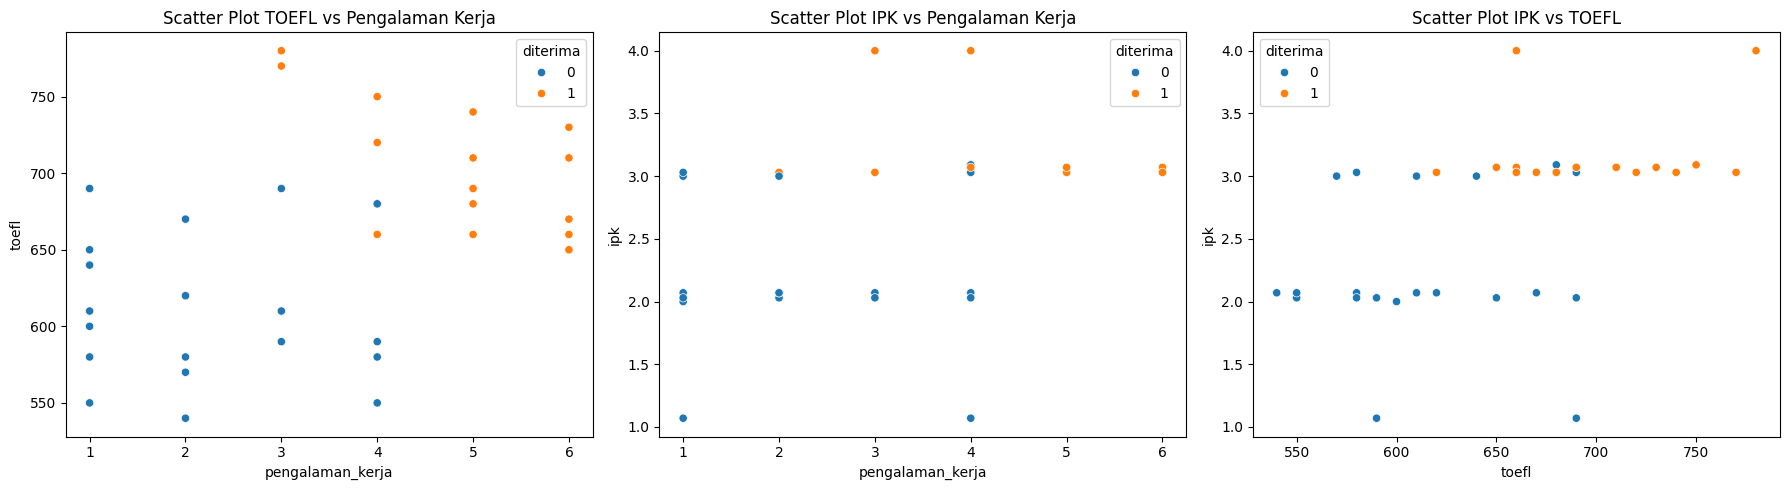

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=cpns, x='pengalaman_kerja', y='toefl', hue='diterima', ax=axes[0])
axes[0].set_title('Scatter Plot TOEFL vs Pengalaman Kerja')

sns.scatterplot(data=cpns, x='pengalaman_kerja', y='ipk', hue='diterima', ax=axes[1])
axes[1].set_title('Scatter Plot IPK vs Pengalaman Kerja')

sns.scatterplot(data=cpns, x='toefl', y='ipk', hue='diterima', ax=axes[2])
axes[2].set_title('Scatter Plot IPK vs TOEFL')

plt.tight_layout()
plt.show()

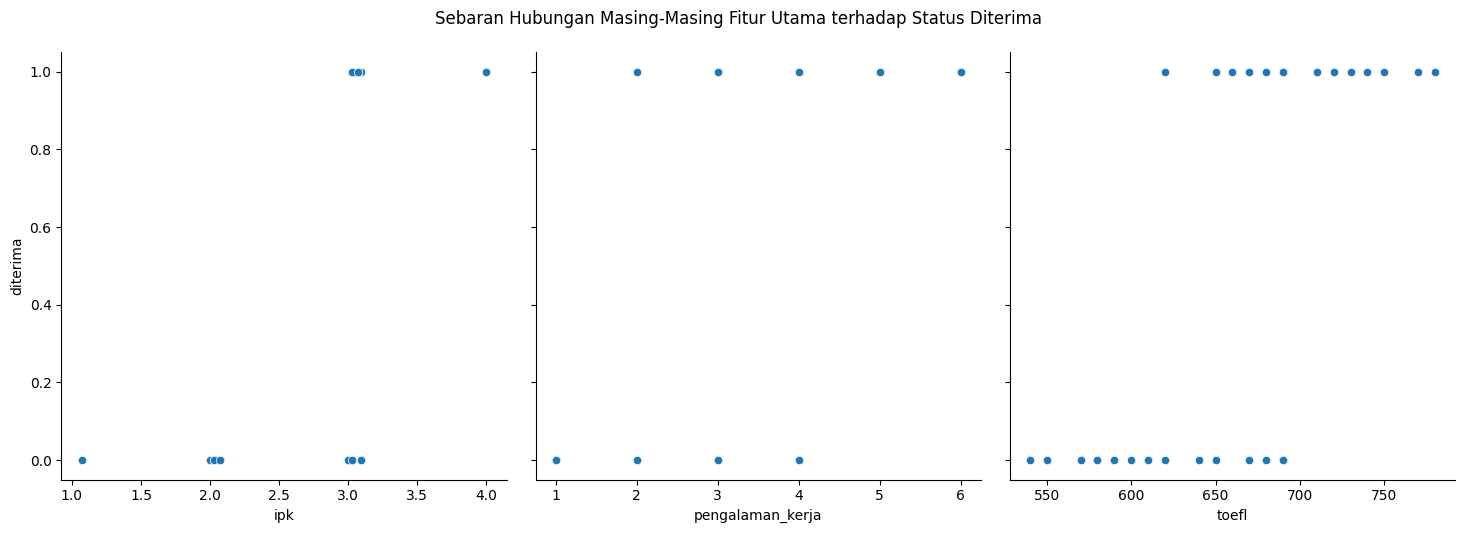

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.PairGrid(cpns,
                 x_vars=['ipk', 'pengalaman_kerja', 'toefl'],
                 y_vars=['diterima'],
                 height=5, aspect=1)
g.map(sns.scatterplot)

plt.suptitle('Sebaran Hubungan Masing-Masing Fitur Utama terhadap Status Diterima',
             y=1.05)
plt.show()

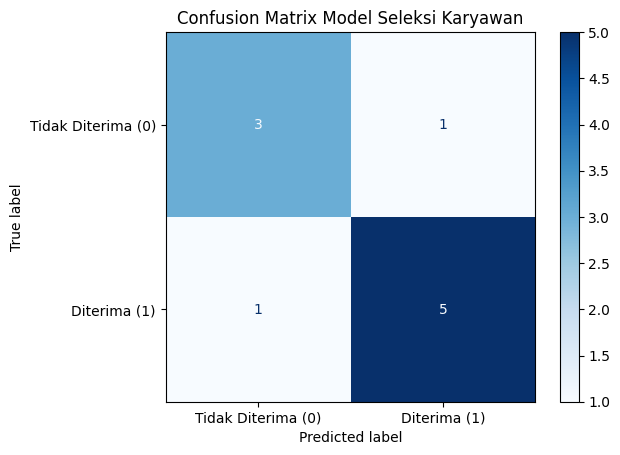

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = cpns[['toefl', 'ipk', 'pengalaman_kerja']]
y = cpns['diterima']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Diterima (0)', 'Diterima (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix Model Seleksi Karyawan')
plt.show()

In [45]:
df_analisis = X_test.copy()
df_analisis['diterima'] = y_test
df_analisis['Prediksi_Diterima'] = y_pred
print(df_analisis[['toefl', 'ipk', 'pengalaman_kerja', 'diterima', 'Prediksi_Diterima']].head(25))

    toefl   ipk  pengalaman_kerja  diterima  Prediksi_Diterima
22    550  2.03                 4         0                  0
20    620  3.03                 2         1                  0
25    670  3.03                 6         1                  1
4     680  3.09                 4         0                  1
10    610  2.07                 3         0                  0
15    610  3.00                 1         0                  0
28    650  3.07                 6         1                  1
11    690  3.07                 5         1                  1
18    650  3.07                 6         1                  1
29    660  3.03                 5         1                  1


In [47]:
df_baru = pd.DataFrame({
    'toefl': [590, 740, 680, 610, 710],
    'ipk': [2, 3.7, 3.3, 2.3, 3],
    'pengalaman_kerja': [3, 4, 6, 1, 5]
})

prediksi_baru = model.predict(df_baru)

df_baru['Status_Prediksi'] = ['Diterima' if p == 1 else 'Tidak Diterima' for p in prediksi_baru]

print("Hasil Prediksi Kelulusan Pelamar Baru:")
print(df_baru)

Hasil Prediksi Kelulusan Pelamar Baru:
   toefl   ipk  pengalaman_kerja Status_Prediksi
0    590  2.00                 3  Tidak Diterima
1    740  3.70                 4        Diterima
2    680  3.30                 6        Diterima
3    610  2.03                 1  Tidak Diterima
4    710  3.00                 5        Diterima
